<a href="https://colab.research.google.com/github/AnotherShittyJoke/ML_GaN_Course-IDU_ITMO-2026/blob/Tsyganov/practice%2004/NN_estate_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Прогнозирование цен на жильё в Санкт-Петербурге

## 1. Постановка задачи

**Задача:** регрессия - предсказание цены квартиры (`price`) по её характеристикам.

**Данные:** Объявления о продаже недвижимости в России за 2021 г., опубликоанные на сайтах avito.ru, realty.yandex.ru, cian.ru, sob.ru, youla.ru, n1.ru, moyareklama.ru. . Признаки включают площадь, этаж, количество комнат, геолокацию и тип здания.

**Метрики качества:**
- MAE (Mean Absolute Error) — средняя абсолютная ошибка
- RMSE (Root Mean Squared Error) — среднеквадратичная ошибка
- R^2 (коэффициент детерминации) — насколько модель объясняет дисперсию

## 2. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')

Используемое устройство: cpu


## 3. Описание данных

In [29]:
# Проверить версию csv потом
df = pd.read_csv('spb_estate.csv')

print('Размер датасета:', df.shape)
print('\nПервые строки:')
df.head()

Размер датасета: (762280, 15)

Первые строки:


,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
0,2021/01/01,3250000,8,9,1,28.70,6.0,59.739495,30.567329,2,0,196657.0,430700.0,78,962850.0
1,2021/01/01,10575058,6,10,3,82.69,15.0,59.748763,30.568178,0,2,196650.0,NaN,78,NaN
2,2021/01/01,4000000,6,18,-1,31.20,0.0,59.813519,30.566873,0,0,196641.0,505999.0,78,2177230.0
3,2021/01/01,7500000,1,10,3,93.80,17.7,59.736433,30.620416,2,0,196655.0,116825.0,78,589354.0
4,2021/01/02,5144156,11,11,2,56.50,0.0,59.771365,30.608975,0,2,196655.0,245638.0,78,2430209.0


In [30]:
print('Типы данных и пропуски:')
print(df.info())

print('\nКоличество пропущенных значений:')
print(df.isnull().sum())

print('\nОсновная статистика:')
df.describe()

Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762280 entries, 0 to 762279
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           762280 non-null  object 
 1   price          762280 non-null  int64  
 2   level          762280 non-null  int64  
 3   levels         762280 non-null  int64  
 4   rooms          762280 non-null  int64  
 5   area           762280 non-null  float64
 6   kitchen_area   762280 non-null  float64
 7   geo_lat        762280 non-null  float64
 8   geo_lon        762280 non-null  float64
 9   building_type  762280 non-null  int64  
 10  object_type    762280 non-null  int64  
 11  postal_code    718271 non-null  float64
 12  street_id      595562 non-null  float64
 13  id_region      762280 non-null  int64  
 14  house_id       664967 non-null  float64
dtypes: float64(7), int64(7), object(1)
memory usage: 87.2+ MB
None

Количество пропущенных значений

,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
count,7.622800e+05,762280.000000,762280.000000,762280.000000,762280.000000,762280.000000,762280.000000,762280.000000,762280.000000,762280.000000,718271.000000,595562.000000,762280.000000,6.649670e+05
mean,1.113031e+07,7.462738,13.920196,1.403724,53.887817,-0.444674,59.932460,30.310239,0.549620,0.901818,195020.679441,350903.585680,77.707146,1.643936e+06
std,7.494436e+07,5.624139,7.053023,1.438358,33.947199,34.100689,0.086958,0.127188,1.221347,0.995169,2884.314583,127618.233713,3.620960,6.105495e+05
min,1.005000e+04,0.000000,0.000000,-1.000000,1.500000,-100.000000,59.653050,29.475135,0.000000,0.000000,187742.000000,116272.000000,1.000000,5.886950e+05
25%,5.249000e+06,3.000000,9.000000,1.000000,33.000000,0.000000,59.863938,30.250611,0.000000,0.000000,193091.000000,257438.500000,78.000000,1.178235e+06
50%,7.239835e+06,6.000000,13.000000,1.000000,44.500000,9.300000,59.939084,30.315900,0.000000,0.000000,196066.000000,338442.000000,78.000000,1.510410e+06
75%,1.121400e+07,10.000000,20.000000,2.000000,64.200000,14.000000,60.000665,30.377370,0.000000,2.000000,197350.000000,460018.000000,78.000000,2.154968e+06
max,9.872180e+09,35.000000,45.000000,9.000000,497.000000,206.000000,60.241984,30.711477,6.000000,2.000000,199406.000000,588258.000000,200.000000,2.839051e+06


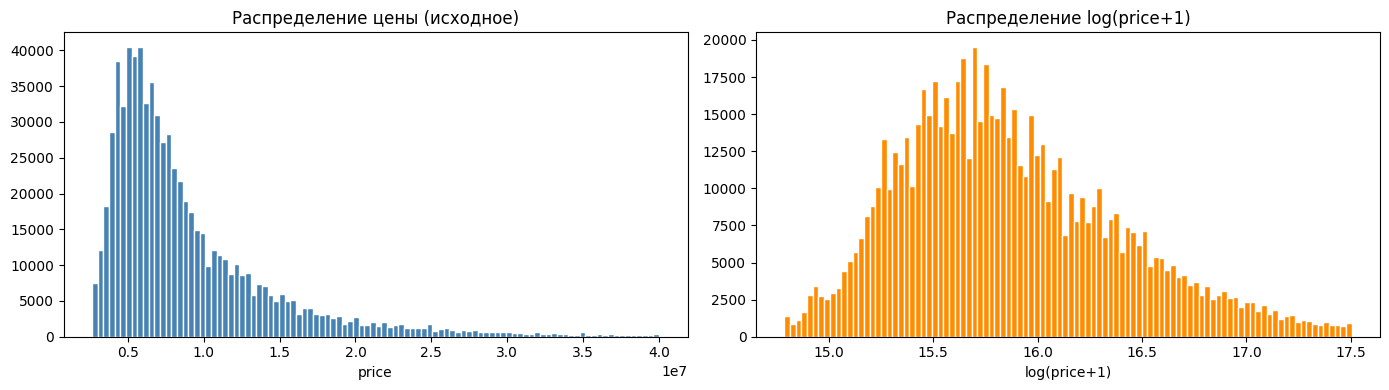

In [49]:
# Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

price_cap = df['price'].quantile(0.995)

axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение цены (исходное)')
axes[0].set_xlabel('price')

axes[1].hist(np.log1p(df['price']), bins=100, color='darkorange', edgecolor='white')
axes[1].set_title('Распределение log(price+1)')
axes[1].set_xlabel('log(price+1)')

plt.tight_layout()
plt.show()

## 4. Подготовка данных

In [32]:
# Удалим явно нерелевантные колонки
# postal_code, street_id, house_id — слишком высокая кардинальность,
# id_region — дублируется геолокацией, date — не используется напрямую
cols_to_drop = ['date', 'postal_code', 'street_id', 'house_id', 'id_region']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print('Колонки после удаления:', df.columns.tolist())

Колонки после удаления: ['price', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'geo_lat', 'geo_lon', 'building_type', 'object_type']


In [33]:
# Обработка пропусков

# Числовые колонки: заполняем медианой
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'price']

for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Строки с пропуском в target удаляем
df = df.dropna(subset=['price'])

print(f'Размер после обработки пропусков: {df.shape}')
print('Оставшиеся пропуски:', df.isnull().sum().sum())

Размер после обработки пропусков: (762280, 10)
Оставшиеся пропуски: 0


In [34]:
# Выбросы

# Цена между 1-м и 98-м перцентилями
p1, p98 = df['price'].quantile([0.01, 0.98])
df = df[(df['price'] >= p1) & (df['price'] <= p98)]

# Площадь между 1-м и 99-м перцентилями
p1_area, p99_area = df['area'].quantile([0.01, 0.99])
df = df[(df['area'] >= p1_area) & (df['area'] <= p99_area)]

# Этаж не может быть больше этажности дома
df = df[df['level'] <= df['levels']]

# Нулевые площади не покупаем
df = df[df['area'] > 0]

print(f'Размер после удаления выбросов: {df.shape}')

Размер после удаления выбросов: (724816, 10)


In [35]:
# Признаки

# Относительный этаж (0 = первый/последний = крайние)
df['floor_ratio'] = df['level'] / df['levels'].clip(lower=1)

# Первый/последний этаж (обычно дешевле)
df['is_first_floor'] = (df['level'] == 1).astype(int)
df['is_last_floor'] = (df['level'] == df['levels']).astype(int)

# Доля кухни от общей площади
df['kitchen_ratio'] = df['kitchen_area'] / df['area'].clip(lower=1)

# Площадь на комнату
df['area_per_room'] = df['area'] / df['rooms'].clip(lower=1)

CENTER_LAT, CENTER_LON = 59.9386, 30.3141
df['dist_to_center'] = np.sqrt(
    (df['geo_lat'] - CENTER_LAT)**2 +
    (df['geo_lon'] - CENTER_LON)**2
)

print('Признаки после инженерии:', df.shape[1])

Признаки после инженерии: 16


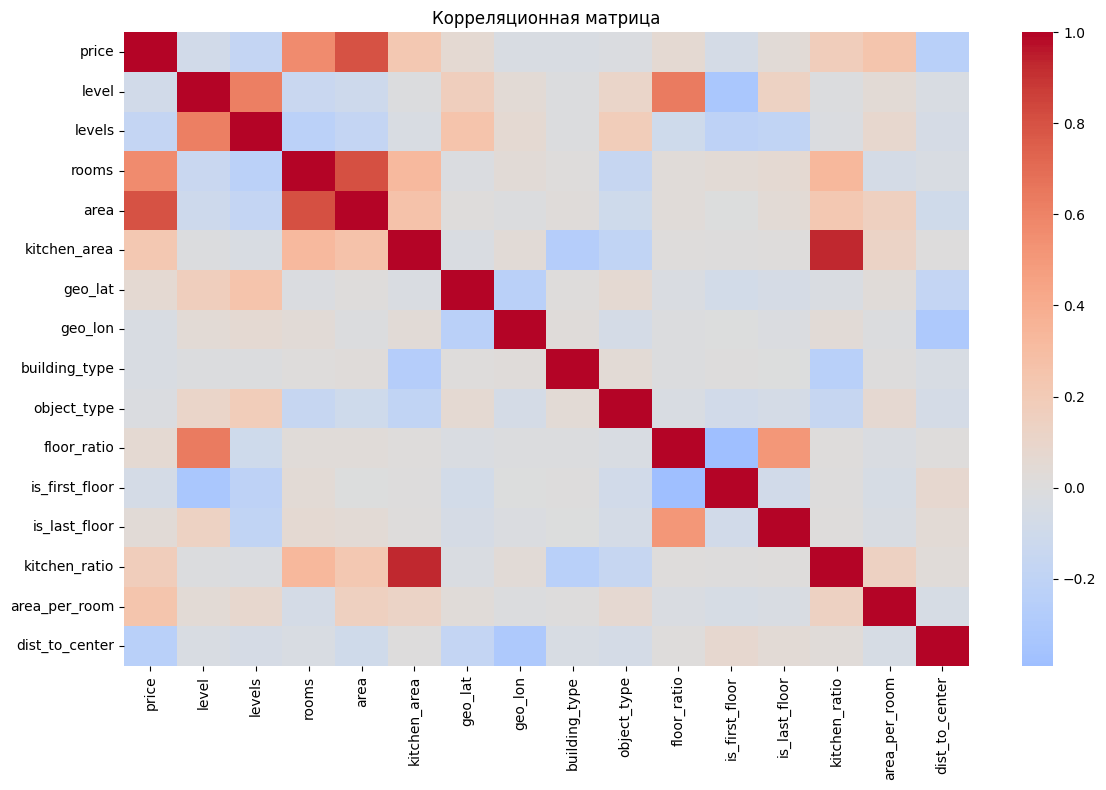

In [36]:
# Корреляционная матрица
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

## 5. Разделение на train / validation / test

In [38]:
# Признаки и целевая переменная
feature_cols = [c for c in df.columns if c != 'price']
X = df[feature_cols].values.astype(np.float32)

# Логарифмируем цену, чтобы распределение стаало ближе к нормальному
y = np.log1p(df['price'].values).astype(np.float32).reshape(-1, 1)

print(f'Признаков: {X.shape[1]}')
print(f'Объектов: {X.shape[0]}')

# Сначала отделяем test (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=44
)

# Из оставшегося - train (80%) и validation (10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=44  # 0.111 * 0.9 ≈ 0.10
)

print(f'\nРазмеры выборок:')
print(f'  Train:      {X_train.shape[0]:>7} ({X_train.shape[0]/X.shape[0]*100:.1f}%)')
print(f'  Validation: {X_val.shape[0]:>7} ({X_val.shape[0]/X.shape[0]*100:.1f}%)')
print(f'  Test:       {X_test.shape[0]:>7} ({X_test.shape[0]/X.shape[0]*100:.1f}%)')

Признаков: 15
Объектов: 724816

Размеры выборок:
  Train:       579924 (80.0%)
  Validation:   72410 (10.0%)
  Test:         72482 (10.0%)


In [39]:
# Нормализация признаков
# scaler обучается только на train, применяем ко всем
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print('Нормализация выполнена')

Нормализация выполнена


## 6. Выбор и описание модели

Используется **MLP (Multilayer Perceptron)** — полносвязная нейронная сеть.

Архитектура:
- Входной слой: количество признаков
- 4 скрытых слоя с убывающей шириной: 256 - 128 - 64 - 32
- Каждый скрытый слой: Linear - BatchNorm - ReLU - Dropout
- Выходной слой: 1 нейрон (предсказание log-цены)

In [40]:
# Dataset
class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# DataLoader
BATCH_SIZE = 512

train_loader = DataLoader(HousingDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(HousingDataset(X_val, y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(HousingDataset(X_test, y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Батчей в train: {len(train_loader)}')
print(f'Батчей в val:   {len(val_loader)}')

Батчей в train: 1133
Батчей в val:   142


In [41]:
# Архитектура MLP
class HousingMLP(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            # Слой 1
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Слой 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Слой 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Слой 4
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # Выход
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train.shape[1]
model = HousingMLP(input_dim=input_dim).to(device)
print(model)

# Количество параметров
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nОбучаемых параметров: {total_params:,}')

HousingMLP(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=32, out_features=1, bias=True)
  )
)

Обучаемых параметров: 48,321


## 7. Обучение модели

In [42]:
#  Функция потерь и оптимизатор
criterion = nn.MSELoss()  # MSE на log-цене
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Learning rate scheduler - уменьшаем lr, если val_loss не улучшается
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print('Оптимизатор и scheduler настроены')

Оптимизатор и scheduler настроены


In [43]:
# Цикл обучения
EPOCHS = 100
PATIENCE = 10

train_losses = []
val_losses   = []

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(1, EPOCHS + 1):

    # ----- Train -----
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(X_batch)

    train_loss /= len(train_loader.dataset)

    # ----- Validation -----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item() * len(X_batch)

    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping на эпохе {epoch}')
        break

# Загружаем лучшую модель
model.load_state_dict(best_model_state)
print(f'\nЛучший Val Loss: {best_val_loss:.4f}')

Epoch   1/100 | Train Loss: 49.1417 | Val Loss: 0.1411
Epoch   5/100 | Train Loss: 0.0830 | Val Loss: 0.0567
Epoch  10/100 | Train Loss: 0.0644 | Val Loss: 0.0588
Epoch  15/100 | Train Loss: 0.0573 | Val Loss: 0.0603
Epoch  20/100 | Train Loss: 0.0536 | Val Loss: 0.0559
Epoch  25/100 | Train Loss: 0.0522 | Val Loss: 0.0546
Epoch  30/100 | Train Loss: 0.0503 | Val Loss: 0.0534
Epoch  35/100 | Train Loss: 0.0504 | Val Loss: 0.0494
Epoch  40/100 | Train Loss: 0.0494 | Val Loss: 0.0531
Epoch  45/100 | Train Loss: 0.0492 | Val Loss: 0.0513
Epoch  50/100 | Train Loss: 0.0488 | Val Loss: 0.0524

Early stopping на эпохе 53

Лучший Val Loss: 0.0493


## 8. Графики loss / метрик

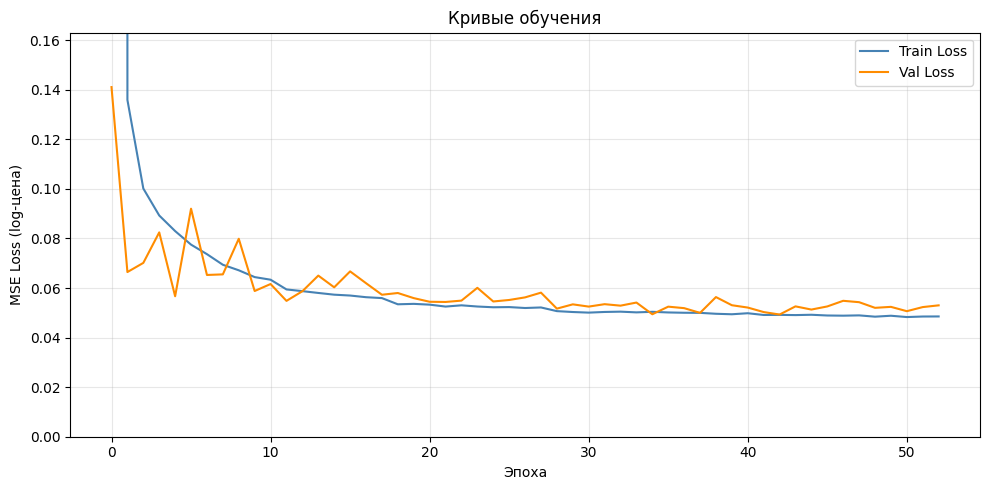

In [48]:
# График обучения
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='darkorange')
plt.ylim(0, max(train_losses[1:] + val_losses[1:]) * 1.2)
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss (log-цена)')
plt.title('Кривые обучения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Оценка на test set

In [45]:
# Предсказания на тесте
model.eval()
all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        all_preds.append(preds)
        all_true.append(y_batch.numpy())

y_pred_log = np.concatenate(all_preds).flatten()
y_true_log = np.concatenate(all_true).flatten()

# Обратное преобразование из log-пространства
y_pred_price = np.expm1(y_pred_log)
y_true_price = np.expm1(y_true_log)

# Метрики
mae  = mean_absolute_error(y_true_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
r2   = r2_score(y_true_price, y_pred_price)

print('=' * 40)
print('РЕЗУЛЬТАТЫ НА TEST SET')
print('=' * 40)
print(f'MAE:  {mae:>15,.0f} руб.')
print(f'RMSE: {rmse:>15,.0f} руб.')
print(f'R^2:   {r2:>15.4f}')
print('=' * 40)

РЕЗУЛЬТАТЫ НА TEST SET
MAE:        1,764,136 руб.
RMSE:       3,196,825 руб.
R^2:            0.6908


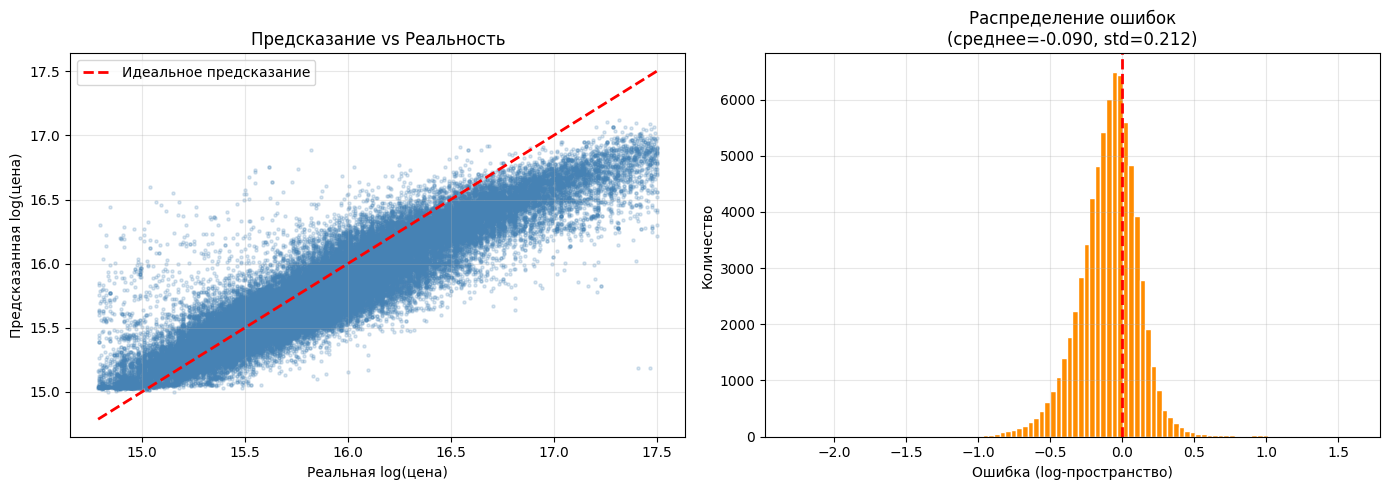

In [46]:
# Визуализация предсказаний
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter предсказанное и реальное (в log-пространстве)
axes[0].scatter(y_true_log, y_pred_log, alpha=0.2, s=5, color='steelblue')
min_val, max_val = y_true_log.min(), y_true_log.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
             label='Идеальное предсказание')
axes[0].set_xlabel('Реальная log(цена)')
axes[0].set_ylabel('Предсказанная log(цена)')
axes[0].set_title('Предсказание vs Реальность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Распределение ошибок
errors = y_pred_log - y_true_log
axes[1].hist(errors, bins=100, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Ошибка (log-пространство)')
axes[1].set_ylabel('Количество')
axes[1].set_title(f'Распределение ошибок\n(среднее={errors.mean():.3f}, std={errors.std():.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
torch.save({
    'model_state_dict': model.state_dict(),
    'feature_cols': feature_cols,
    'scaler': scaler,
}, 'estate_model.pth')

print('Модель сохранена в estate_model.pth')

Модель сохранена в estate_model.pth


## 10. Выводы

В данном проекте была решена задача регрессии — предсказание цены квартиры по её характеристикам.

**Что было сделано:**
- Проведена разведочная аналитика данных (EDA)
- Выполнена очистка: заполнение пропусков, удаление выбросов, фильтрация некорректных записей
- Добавлены новые признаки (floor_ratio, kitchen_ratio, area_per_room)
- Целевая переменная логарифмирована для нормализации распределения
- Данные разделены на train / validation / test - (80% / 10% / 10%)
- Обучена полносвязная нейронная сеть (MLP) на PyTorch с BatchNorm и Dropout
- Использованы: Adam оптимизатор, ReduceLROnPlateau и early stopping

**Результаты:** модель достигла R^2 = 0.69, что означает, что нейронная сеть объясняет значительную долю вариативности цен на жильё. Нормальный результат угадывания для простого MLP без сложных признаков.

Разрыв между MAE и RMSE говорит о том, что на элитных квартирах модель всё ещё ошибается сильнее - проблема с предсказанием уникальных объектов.